In [14]:
import numpy as np
from numpy.random import default_rng
random =default_rng(0)
from math import log
from matplotlib import pyplot as plt
import policy as pol
from tqdm import tqdm
from numba import jit

# Bandit loop
We consider an agent interacting with a stochastic bandit, and we repeat the experience for a certain random of trials. The repetition process is vectorized so we avoid a for loop: we run the different trials in parallel.

## Reward generation at each round
Either we call the random generation routine, or we access a predefined table corresponding to the reward table model. This latter can reduce execution time at the price of memory allocation.


In [18]:
n_repetitions= 1000
horizon = 10000
true_means = np.linspace(0.1, 0.9, 2)
n_arms = len(true_means)
assert n_arms <= horizon, "The horizon must be at least equal to the number of arms !"

reward_tensor = random.binomial(1, true_means, (horizon, n_repetitions, n_arms)).astype('int8')
#reward_tensor = random.normal(loc= true_means, size= (horizon, n_repetitions, n_arms))

def run_algorithm(true_means, horizon, reward_tensor, policy):
    actions = []
    rewards = []
    # initialization: pull each arm once
    ones_rep = np.ones(n_repetitions, dtype= 'uint8')
    for t in range(n_arms):
        actions.append(t*ones_rep)
        rewards.append(reward_tensor[t, np.arange(n_repetitions), actions[-1]])

    cumul_rewards = np.array(rewards, dtype= 'float64')
    n_pulls = np.ones((n_arms, n_repetitions), dtype= "int")


    # run n_repetitions experiments in a vectorized way

    for t in tqdm(range(n_arms, horizon)):
        
        # play action / pull arm
        actions.append(policy(cumul_rewards, n_pulls, horizon**2))
    
        # collect reward from pulled arm
        rewards.append(reward_tensor[t,np.arange(n_repetitions),actions[-1]])

        # update the empirical mean of the played arm
        act_rep_tuple =  (actions[-1], np.arange(n_repetitions)) 
        cumul_rewards[act_rep_tuple] += rewards[-1]
        n_pulls[act_rep_tuple] += 1
    return actions, rewards

actions, rewards = run_algorithm(true_means, horizon, reward_tensor, pol.ucb1_jit)

100%|██████████| 9998/9998 [00:03<00:00, 2684.44it/s]


# Plotting the regret
Having stored the rewards, there are two ways to estimate the expected regret:
* Taking the sum of the realized regrets (although in our case, the oracle's reward is already averaged), and then taking the average over experiments.
  $$R_{\text{realized}}(T) = \sum_{t=1}^T (r_{a^\star} - r_{a_t})$$
  where $r_{a_t} \sim \mathcal P_{a_t}$.
  
* Semi-realized regret, where a expecatation is taken for the oracle:
  $$R_{\text{realized}}(T) = \sum_{t=1}^T (\mu_{a^\star} - r_{a_t})$$
* Taking the sum of the expectation of regret conditional on the taken action, since we know the true mean
$$R_{\text{pseudo}}(T) = \sum_{t=1}^T (\mu_{a^\star} - \mu_{a_t}),$$
followed by an averaging over all trials. This way, we have a much smoother regret with a moderate number of trials.


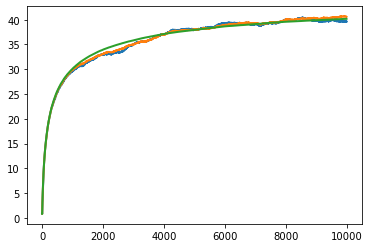

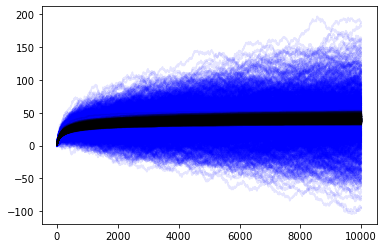

In [19]:
agent_cumul_reward = np.cumsum(rewards, axis= 0)
expected_rewards = true_means[np.array(actions)]
cumul_expected_reward = np.cumsum(expected_rewards, axis= 0)
oracle_expec_cumul_reward = (np.arange(horizon)+1)*true_means.max()
oracle_realized_cumul_reward = np.cumsum(random.binomial(1,true_means.max(), (horizon, n_repetitions)),
axis= 0)


plt.figure()
horizon_range = np.arange(horizon)+1
realized_regret = oracle_realized_cumul_reward - agent_cumul_reward
semi_realized_regret = oracle_expec_cumul_reward[:,None] - agent_cumul_reward
pseudo_regret = oracle_expec_cumul_reward[:,None] - cumul_expected_reward
plt.plot(horizon_range, realized_regret.mean(axis= 1), linewidth= 2)
plt.plot(horizon_range, semi_realized_regret.mean(axis= 1), linewidth= 2)
plt.plot(horizon_range, pseudo_regret.mean(axis= 1), linewidth= 2)
plt.savefig("regret.png", format= "png")# %%

plt.figure()
plt.plot(horizon_range, realized_regret, 'b', alpha= 0.1)
plt.plot(horizon_range, pseudo_regret, 'k', alpha= 0.1)
plt.savefig("regret_realizations.png", format= "png")# %%


array([[  19, -128, -128, -128,  -62,  -72,   62, -128, -120,   28, -128,
         -72,  -86,  -99,  -98, -128, -128,   71,  -69,   74,   89, -128,
        -128, -128,   13, -128,   30, -128, -128, -128, -128, -128, -128,
        -128, -128, -128, -128, -128, -128, -128, -128,  -50,   50,   -1,
         -85, -128, -128, -119,  -14,   72, -126,  -24, -128,   30, -105,
        -128,   26,  -17, -124,   14, -100,  -87, -128, -128, -128, -128,
          88,  -39, -128, -128, -128,   88, -128, -116, -112, -128, -128,
          -7, -128,  110, -128,   14,   95, -128, -128,   57,  -71, -128,
        -128,  -65,   81, -128,   85, -128,  -31,  -15,  -11, -128, -128,
         -36],
       [-128,  -66,  103,   76, -128, -128, -128,  107, -128, -128,  -34,
        -128, -128, -128, -128, -126,  110, -128, -128, -128, -128,   51,
          14,   39, -128,  -79, -128,  125,  -87,   35,   26, -114,   -9,
           5,  -13,  101,   12,  107, -108,   53,   80, -128, -128, -128,
        -128,  112,  -5

# Pull trajectory representation
We represent the trajectory of arms:
* As a walk in a space spanned by arms, with mean as velocity. This is only available for 2 arms, Maybe for more than 2, one can try a dim reduction approach,

In [1]:
assert n_arms == 2, "cannot represent more than two arms !"
actions_x, actions_y = (true_means[actions==1], true_means[actions==0])
plt.plot(np.cumsum(actions_x, axis= 0), np.cumsum(actions_y, axis= 0),color= 'k', alpha= 0.3);


NameError: name 'n_arms' is not defined

In [7]:
actions.shape

(10000, 1000)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

array([[  19, -128, -128, -128,  -62,  -72,   62, -128, -120,   28, -128,
         -72,  -86,  -99,  -98, -128, -128,   71,  -69,   74,   89, -128,
        -128, -128,   13, -128,   30, -128, -128, -128, -128, -128, -128,
        -128, -128, -128, -128, -128, -128, -128, -128,  -50,   50,   -1,
         -85, -128, -128, -119,  -14,   72, -126,  -24, -128,   30, -105,
        -128,   26,  -17, -124,   14, -100,  -87, -128, -128, -128, -128,
          88,  -39, -128, -128, -128,   88, -128, -116, -112, -128, -128,
          -7, -128,  110, -128,   14,   95, -128, -128,   57,  -71, -128,
        -128,  -65,   81, -128,   85, -128,  -31,  -15,  -11, -128, -128,
         -36],
       [-128,  -66,  103,   76, -128, -128, -128,  107, -128, -128,  -34,
        -128, -128, -128, -128, -126,  110, -128, -128, -128, -128,   51,
          14,   39, -128,  -79, -128,  125,  -87,   35,   26, -114,   -9,
           5,  -13,  101,   12,  107, -108,   53,   80, -128, -128, -128,
        -128,  112,  -5